<a href="https://colab.research.google.com/github/christinengalle19-collab/Assignement2New/blob/main/Assignment12ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import random


In [3]:
# 1️ Load the Fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


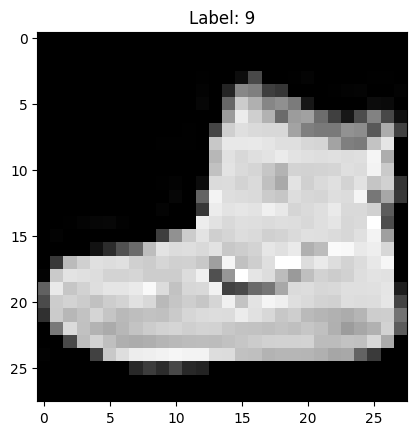

In [4]:
import matplotlib.pyplot as plt
# Display the first training image
plt.imshow(X_train[0], cmap='gray')  # cmap='gray' because images are grayscale
plt.title(f"Label: {y_train[0]}")
plt.show()

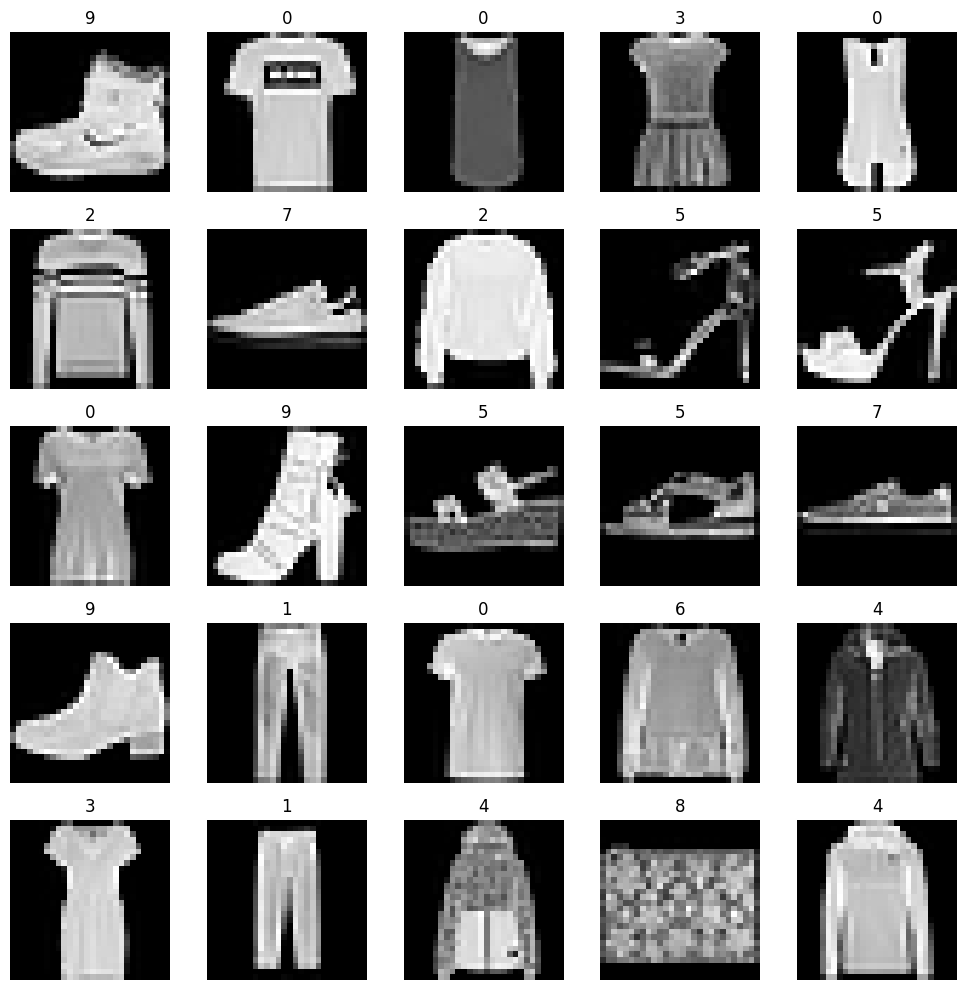

In [5]:
# Plot first 25 images in a 5x5 grid
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
# 2Normalize pixel values (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

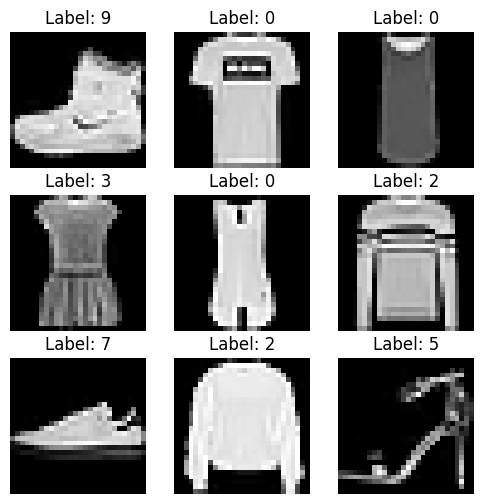

In [7]:
# 3️ Visualize some sample images
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8229 - loss: 0.5012 - val_accuracy: 0.8508 - val_loss: 0.4209
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8645 - loss: 0.3755 - val_accuracy: 0.8400 - val_loss: 0.4404
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8773 - loss: 0.3383 - val_accuracy: 0.8630 - val_loss: 0.3765
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8850 - loss: 0.3129 - val_accuracy: 0.8722 - val_loss: 0.3499
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8903 - loss: 0.2965 - val_accuracy: 0.8794 - val_loss: 0.3436
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8955 - loss: 0.2799 - val_accuracy: 0.8790 - val_loss: 0.3438
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9003 - loss: 0.2686 - val_accuracy: 0.8800 - val_loss: 0.3383
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9040 - loss: 0.2570 -

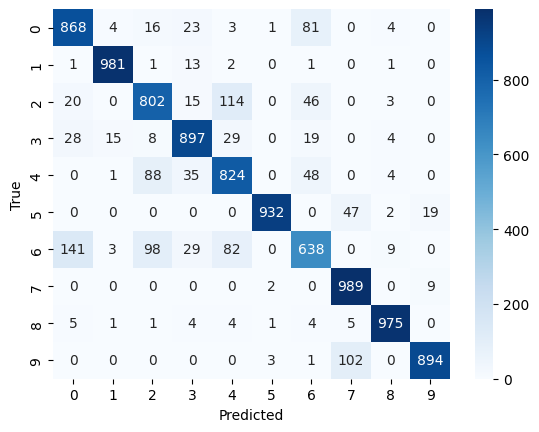

In [8]:
#implement the confusion matrix
model = keras.Sequential([
    keras.Input(shape=(28,28)), # Use an explicit Input layer
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Compile the model before making predictions
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


# Make predictions on the test data
y_pred_probs = model.predict(X_test)
# Convert prediction probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

#INTERPRETATION    

##Looking at this confusion matrix, I can see that the model performs strongly overall, with most predictions falling along the diagonal, meaning the majority of digits are correctly classified. However I immediately notice systematic confusion patterns: digits like 0, 2, 4, and 6 are frequently misclassified with one another, which reflects the natural similarity in certain handwritten styles and the limitations of a simple feedforward network that does not capture spatial structure.
## In contrast, digits such as 1,3,5, 7, 8, and 9 show very high accuracy, indicating that their shapes are distinct enough for the model to learn reliably. The matrix also reveals that the model tends to overpredict certain classes, especially 6, when uncertain. Overall, the confusion matrix confirms that the model is competent but still constrained by architecture, and that a convolutional neural network would significantly reduce these recurring misclassification patterns by learning richer visual features.


In [12]:
model = keras.Sequential([
    keras.Input(shape=(28,28,1)), # Use an explicit Input layer, adding a channel dimension
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.8228 - loss: 0.4850 - val_accuracy: 0.8622 - val_loss: 0.3915
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8853 - loss: 0.3142 - val_accuracy: 0.8900 - val_loss: 0.3098
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9017 - loss: 0.2676 - val_accuracy: 0.8888 - val_loss: 0.2986
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9123 - loss: 0.2386 - val_accuracy: 0.8960 - val_loss: 0.2826
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9196 - loss: 0.2166 - val_accuracy: 0.9031 - val_loss: 0.2660
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9269 - loss: 0.1959 - val_accuracy: 0.9013 - val_loss: 0.2814
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9332 - loss: 0.1781 - val_accuracy: 0.9050 - val_loss: 0.2721
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9396 - loss: 0.1614 -

#Application Demonstration

##In a fashion retail and e‑commerce context, an image classification model can be deployed to automate the visual organization of product catalogs. By automatically classifying photos of T‑shirts, shoes, bags, or coats, the company improves visual search, accelerates product uploads, and reduces human errors in labeling. To operate at scale, the system must be capable of processing thousands of images per day, either in batch mode on CPU/GPU servers or in streaming mode for platforms that require continuous ingestion. In real‑time applications, latency becomes critical: the image uploaded by a seller or customer must be analyzed within milliseconds to ensure a smooth user experience.

###Technical integration is typically achieved through a REST API (Flask or FastAPI), connected to a product database and an image ingestion pipeline. Compared to traditional machine learning approaches based on handcrafted descriptors such as HOG or SIFT, deep learning offers clear superiority: it automatically learns complex visual representations, enabling the model to better capture variations in texture, shape, and style found in fashion images. This ability to abstract visual patterns makes neural networks particularly well suited to the rich and diverse visual environments of online commerce.

#Colab link https://colab.research.google.com/drive/10uoDZYoqAjfWhJz-tTD0StO3QVcEVU-3?usp=sharing

##github link